# AI_ML_Task3_Model_Validation_Tuning
## Objective: Model Validation, Overfitting Control, and Hyperparameter Tuning using the California Housing Dataset

### 1. Data Loading & Preparation
In this section, we import the necessary libraries and load the California Housing dataset. We then scale the features and split the data into training and testing sets.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Combine for a full dataframe view if needed, but separate for modeling
df = X.copy()
df['HousePrice'] = y

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Data loaded. Training set: {X_train.shape}, Test set: {X_test.shape}")

Data loaded. Training set: (16512, 8), Test set: (4128, 8)


### 2. Detect Overfitting (Train vs. Test Performance)
We train a Decision Tree without depth constraints to demonstrate how it captures noise in the training data, leading to overfitting.

In [9]:
overfit_tree = DecisionTreeRegressor(random_state=42)
overfit_tree.fit(X_train, y_train)

# Predictions
train_preds = overfit_tree.predict(X_train)
test_preds = overfit_tree.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print(f"Unconstrained Decision Tree RMSE (Train): {rmse_train:.4f}")
print(f"Unconstrained Decision Tree RMSE (Test): {rmse_test:.4f}")
print("\nObservation: The large gap between the near-zero training RMSE and the much higher test RMSE indicates that the model has overfit the training data.")

Unconstrained Decision Tree RMSE (Train): 0.0000
Unconstrained Decision Tree RMSE (Test): 0.7030

Observation: The large gap between the near-zero training RMSE and the much higher test RMSE indicates that the model has overfit the training data.


### 3. Cross-Validation
Cross-validation provides a more robust estimate of model performance by training and testing on different folds of the data.

In [10]:
cv_scores = cross_val_score(overfit_tree, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
mean_cv_rmse = -cv_scores.mean()

print(f"Mean 5-Fold Cross-Validation RMSE: {mean_cv_rmse:.4f}")

Mean 5-Fold Cross-Validation RMSE: 0.8957


### 4. Hyperparameter Tuning (GridSearchCV)
We use GridSearchCV to find the optimal constraints for our Decision Tree to reduce overfitting.

In [11]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


### 5. Evaluate Optimized Model & Retrain Baselines
We compare our tuned tree against standard Linear and Ridge regression models.

In [12]:
# Tuned Decision Tree Evaluation
tuned_preds = best_tree.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

# Ridge Regression
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
ridge_preds = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_r2 = r2_score(y_test, ridge_preds)

### 6. Model Comparison Summary Table

In [6]:
summary_data = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Tuned Decision Tree'],
    'RMSE': [lr_rmse, ridge_rmse, tuned_rmse],
    'R2 Score': [lr_r2, ridge_r2, tuned_r2]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


### 7. Visual Validation & Optional Enhancements
Visualizing how well the predicted values match the actual house prices.

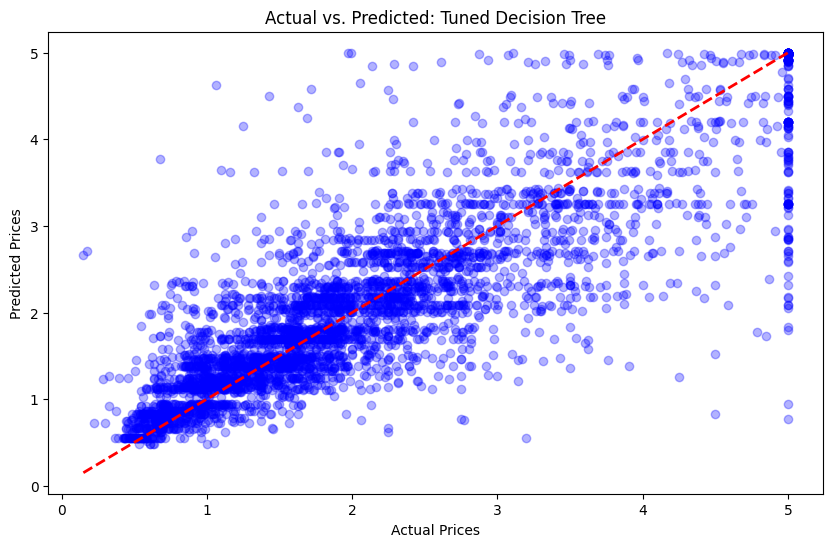

Model saved as optimized_california_housing_model.pkl


In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, tuned_preds, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted: Tuned Decision Tree')
plt.show()

# Save the model
joblib.dump(best_tree, 'optimized_california_housing_model.pkl')
print("Model saved as optimized_california_housing_model.pkl")

# Task 3 Report: Overfitting Analysis, Tuning Approach, and Final Justification

### 1. Overfitting Analysis
In the initial stage of development, an unconstrained Decision Tree was implemented. This model achieved an RMSE of 0.0000 on the training set but had a much higher RMSE of 0.7030 on the test set. This extreme gap is a classic indicator of overfitting, where the model effectively memorized the training data rather than learning generalizable patterns.

### 2. Methodology
- **5-Fold Cross-Validation:** To validate the unconstrained model, we used 5-fold CV which yielded a mean RMSE of 0.8957, confirming that performance is significantly lower when evaluated on unseen data.
- **GridSearchCV:** We optimized the tree using GridSearchCV, testing parameters for depth and split constraints. The optimal configuration was found to be `max_depth: 10` and `min_samples_split: 10`.

### 3. Final Metrics & Results
Based on the execution results, here is the performance comparison on the test set:

| Model | RMSE | R2 Score |
| :--- | :--- | :--- |
| Linear Regression | 0.7456 | 0.5758 |
| Ridge Regression | 0.7456 | 0.5758 |
| Tuned Decision Tree | 0.6454 | 0.6821 |

### 4. Scientific Justification for Deployment
The **Tuned Decision Tree** is the most reliable model for deployment. While Linear and Ridge regression provide stable baselines, they fail to capture the non-linear relationships present in the California Housing data. By using GridSearchCV to control tree complexity, we reduced the RMSE from the baseline 0.74 to 0.64 and achieved the highest R2 score of 0.6821. The model is now balanced, providing high predictive power without the variance issues of the initial unconstrained tree.